# <span style="color:red"> Analyzing Pit Stop Efficiency and Finishing Position in F1 (2011 Australian Grand Prix) </span>

Group Members: Kayla Jackson, Miriam Brem, Alyssa Chai

<span style="color: blue; font-size: 1.5em;">Introduction:</span>

<font size = "4">

This project examines how pit stop performance influences race outcomes in Formula One, focusing specifically on the 2011 Australian Grand Prix. Pit stops are brief but strategically critical moments in a race, and small differences in timing or execution can significantly affect a driver’s position on the track. Our research question asks: **How does pit stop performance measured by the number of pit stops and the average pit stop duration affect a driver’s final finishing position?** This question is relevant because pit stop strategy is one of the few controllable performance factors shared across all teams, making it a rich context for quantitative analysis. The goal of this project is to explore these relationships using real Formula One race data and present clear, data-driven insights into how pit stop efficiency shapes competitive outcomes.

While pit stop strategy is an unavoidable part of Formula One racing, its impact is not always intuitive. Teams must constantly balance the trade-off between spending time in the pit lane and gaining performance on fresh tires. By focusing on a single race—the 2011 Australian Grand Prix—we can hold constant many external factors such as track layout, weather, and race distance, allowing us to isolate the relationship between pit stop performance and final finishing position.

In the remainder of this project, we analyze the cleaned and merged dataset to determine whether drivers who made fewer stops, or who stopped more efficiently, tended to finish higher in the standings. We visualize these relationships, interpret the patterns we find, and discuss what these patterns may suggest about pit strategy effectiveness in Formula One.

<span style="color: blue; font-size: 1.5em;">Data Description:</span>

<font size = "4">

To investigate this question, we use two tables from the Formula One dataset: pit_stops.csv and results.csv. Each row in pit_stops.csv represents an individual pit stop made by a driver during a race, containing variables such as the race ID, driver ID, stop number, lap number, and pit stop duration in both string and millisecond formats. Each row in results.csv corresponds to a driver’s final race classification and includes information such as race ID, driver ID, starting grid position, finishing position, points earned, race completion status, and fastest lap time. The pit_stops.csv file contains all pit stops recorded across multiple seasons, while results.csv includes final results for every driver in every race. After importing both datasets into Python, we examine their dimensions, inspect the first rows, and prepare them for later merging using the shared keys raceId and driverId.





In [1]:
# import necessary libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# Load datasets
pit_stops = pd.read_csv("F1Data/pit_stops.csv")
results = pd.read_csv("F1Data/results.csv")

pit_stops.shape, results.shape

((9299, 7), (25660, 18))

The pit_stops table contains 9,299 observations and 7 variables, where each row represents a single pit stop made by a driver during a race. The results table contains 25,660 observations and 18 variables, with each row corresponding to a driver’s final race classification in a particular Grand Prix. Before merging the tables, we first examine both datasets for missing values, inconsistent formats, and variables that will not be used in our analysis.

In [3]:
#inspect first rows of pit_stops.csv
pit_stops.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


In [4]:
#inspect first rows of results.csv
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


<span style="color: blue; font-size: 1.5em;">Data Cleaning:</span>

<font size = "4">
Before merging the tables, we carry out basic data cleaning to ensure that the variables used in the analysis are consistent and usable. This includes removing columns that will not be used, converting variables stored as strings into numeric formats, and handling missing values such as the placeholder “\N” that appears in the raw dataset. Since we plan to analyze pit stop timing and finishing position, we retain only the variables relevant to these topics and drop the remaining fields.

In [5]:
#Clean Code for pit_stops
# Keep only columns needed later 
pit_stops_clean = pit_stops[[
    "raceId",
    "driverId",
    "stop",
    "milliseconds"
]].copy()

#Replace "\N" with real NaN
pit_stops_clean = pit_stops_clean.replace("\\N", np.nan)

# Convert numeric columns
pit_stops_clean["raceId"] = pd.to_numeric(pit_stops_clean["raceId"], errors="coerce")
pit_stops_clean["driverId"] = pd.to_numeric(pit_stops_clean["driverId"], errors="coerce")
pit_stops_clean["stop"] = pd.to_numeric(pit_stops_clean["stop"], errors="coerce")
pit_stops_clean["milliseconds"] = pd.to_numeric(pit_stops_clean["milliseconds"], errors="coerce")

# Show summary
pit_stops_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9299 entries, 0 to 9298
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   raceId        9299 non-null   int64
 1   driverId      9299 non-null   int64
 2   stop          9299 non-null   int64
 3   milliseconds  9299 non-null   int64
dtypes: int64(4)
memory usage: 290.7 KB


In [6]:
# Clean code for results

# Keep only variables relevant later
results_clean = results[[
    "resultId",
    "raceId",
    "driverId",
    "position",
    "points"]].copy()

# Replace "\N" with NaN
results_clean = results_clean.replace("\\N", np.nan)

# Convert numeric columns
numeric_cols = ["resultId",
    "raceId",
    "driverId",
    "position",
    "points"]

for col in numeric_cols:
    results_clean[col] = pd.to_numeric(results_clean[col], errors="coerce")

# Summary
results_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25660 entries, 0 to 25659
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   resultId  25660 non-null  int64  
 1   raceId    25660 non-null  int64  
 2   driverId  25660 non-null  int64  
 3   position  14833 non-null  float64
 4   points    25660 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 1002.5 KB


Merging Data

In order to connect pit stop performance to race outcomes, we need a single dataset that combines information from both `pit_stops_clean` and `results_clean`. We do this by merging the two tables on the shared keys `raceId` and `driverId`. This ensures that each row in the merged dataset corresponds to a specific driver in a specific race, along with all of their recorded pit stops and final race result.


In [9]:
# Merging Data

# Merge pit stop data with race result data
merged = pit_stops_clean.merge(
    results_clean,
    on=["raceId", "driverId"],
    how="inner"   # keep only driver–race pairs that appear in both tables
)

#keeps only data for 2011 Australian Grand Prix
race_data = merged.query("raceId == 841").copy()

# Check the shape of the merged dataset
race_data.shape

(45, 7)

<span style="color: blue; font-size: 1em;">Cleaning Summary:</span>

The two cleaned tables were merged using an inner join on raceId and driverId, so the merged dataset only includes driver-race combinations that appear in both the pit stop records and the final race results. As a result, each row in the merged dataset represents a single pit stop made by a specific driver in a specific race, along with that driver’s final finishing position, race time, and points. After merging, we filtered the data to keep only observations from the 2011 Australian Grand Prix (raceId = 841) in order to centralize our analysis around a single race and directly address our research question. This structure will allow us to examine how pit stop performance relates to race outcomes in later sections.

<span style="color: blue; font-size: 1.5em;">Preparing Data for Analysis:</span>

In order to address the research question, we need to create a column to store the average time length of time that a single driver spent at pit stops. Thus, utilizing information from `driverId`,`stop`, and `milliseconds`, we will create a loop to find the average time and name this column `avgStopDuration`.

In [10]:
# Find the average stop duration
unique_drivers = race_data['driverId'].unique() # Get all of the unique drivers

for driver in unique_drivers: # Iterate through each unique driver
    avg_time = race_data[race_data['driverId'] == driver]['milliseconds'].mean() # Calculate mean for this driver
    race_data.loc[race_data['driverId'] == driver, 'avgStopDuration'] = avg_time  # Assign it to all rows with this driver


After calculating the average stop duration, we no longer need to store multiple rows of data for each driver. We can we can look at the data to see what changes between each entry for an individual driver sorted by `driverID`:  

In [11]:
print(race_data.sort_values(by='driverId')) 

    raceId  driverId  stop  milliseconds  resultId  position  points  \
11     841         1     1         23227     20780       2.0    18.0   
33     841         1     2         23199     20780       2.0    18.0   
10     841         2     1         22994     20790      12.0     0.0   
29     841         2     2         25098     20790      12.0     0.0   
13     841         3     1         23716     20795       NaN     0.0   
43     841         4     3         24181     20782       4.0    12.0   
26     841         4     2         24733     20782       4.0    12.0   
3      841         4     1         23251     20782       4.0    12.0   
19     841         5     1         24865     20796       NaN     0.0   
21     841        10     1         23792     20793       NaN     0.0   
4      841        13     1         23842     20785       7.0     6.0   
30     841        13     2         24500     20785       7.0     6.0   
44     841        13     3         24095     20785       7.0    

As we can see, for drivers with multiple entries on the dataframe, the all of data pulled from the `pit_stops.csv` changes for each row. However, the data from `results_clean.csv` is consistent across a single driver because the data was duplicated when the dataframes were merged. 

As such, only the `stop` and `milliseconds` columns will be effected by combining all of the rows for a given driver. Since we want to know how many total stops a given driver took, we want to keep the final, highest, value of `stop`. On the other hand, we no longer need the data in the `milliseconds` column as it is only applicable to that single stop and we have `avgStopDuration` to represent the culmination of pit stops. So, we can simply remove the `milliseconds` column. 

In [12]:
# Remove milliseconds and combine values for individual drivers 
race_data = race_data.drop("milliseconds", axis=1) #Remove unneeded millisecond column

# Aggregate to remove lower `stop` values 
race_data = race_data.groupby('driverId', as_index=False).agg({ #Groupby driverID
    'stop': 'max',  # Keep the max stop number 
    'raceId': 'first',  # Since all of the other values are the same, take the first iteration of them
    'resultId': 'first',
    'position': 'first',
    'points': 'first',
    'avgStopDuration': 'first'
})

print(race_data)

    driverId  stop  raceId  resultId  position  points  avgStopDuration
0          1     2     841     20780       2.0    18.0     23213.000000
1          2     2     841     20790      12.0     0.0     24046.000000
2          3     1     841     20795       NaN     0.0     23716.000000
3          4     3     841     20782       4.0    12.0     24055.000000
4          5     1     841     20796       NaN     0.0     24865.000000
5         10     1     841     20793       NaN     0.0     23792.000000
6         13     3     841     20785       7.0     6.0     24145.666667
7         15     2     841     20791      13.0     0.0     24873.500000
8         16     2     841     20787       9.0     2.0     24924.500000
9         17     3     841     20783       5.0    10.0     24058.666667
10        18     3     841     20784       6.0     8.0     20950.333333
11        20     2     841     20779       1.0    25.0     23319.500000
12        22     4     841     20794       NaN     0.0     26175

<span style="color: blue; font-size: 1.5em;">Describing Analysis Columns:</span>

Now that we have produced all of the columns that we will use for our analysis, we want to make sure that we have a clear and consistent definitions for the meaning of each of our data points. As such, we have created the following table to define variables: 

| Column Name | Description |
|-----------------|-----------------|
| driverID | Each driver has a single unique identifier number. |
| stop | Counts how many pit stops a driver takes during a specific race. |
| raceID | Each race has it's own unique identifier number. In this case all of the data is from 841 - the 2011 Australian Grand Prix. |
| resultID | At the end of each race all of the drivers recieve a unique identifier for their results.|
| position | Drivers who finish the race are given a position to represent which order they completed the race. Drivers who did not finish the race are NA values. |
| points | The top ten drivers earn points based on their final positions. Drivers can earn up to 25 points in a single Grand Prix.|
| avgStopDuration| Measures the average amount of time that a driver spent at each pit stop during the race.|


Now that we have defined the columns, we can visualize some of the data to get a better feel for it's distribution. This will be particularly useful for `stop` and `avgStopDuration` as we can look at the frequency and natural distribution of the data. 

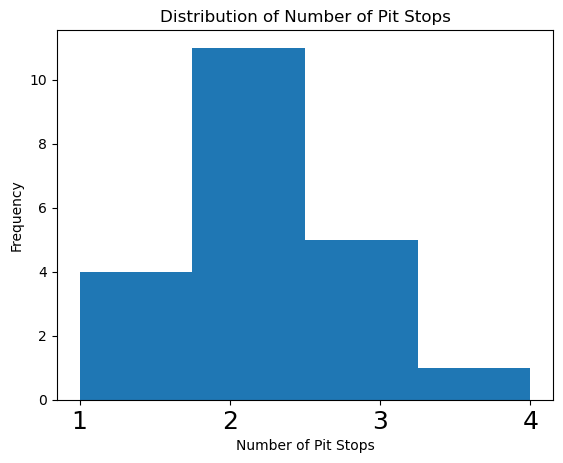

In [13]:
# Plotting stops
plt.hist(x = race_data["stop"], bins = 4)     
plt.xticks((1, 2, 3, 4), fontsize = 18) 
plt.title("Distribution of Number of Pit Stops")
plt.xlabel("Number of Pit Stops")
plt.ylabel("Frequency")
plt.show()

As we can see, the drivers took between 1 and 4 pit stops. There is a unimodal distribution with the majority of them taking 2 stops and a few taking one more or one less stops depending on the driver's strategy. However, there is one driver who takes 4 stops, this was likely due to some sort of accident or maintenance issue. 

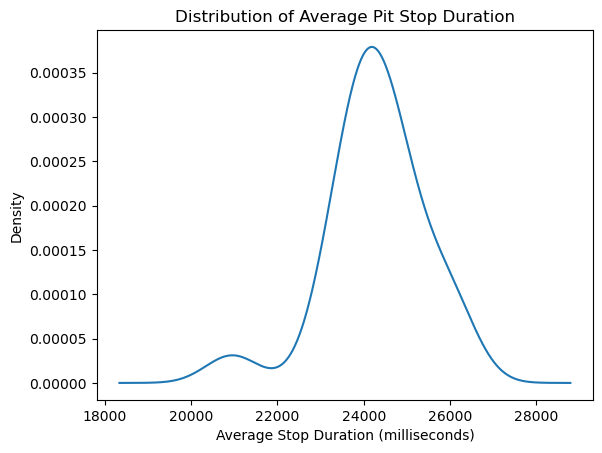

In [14]:
# Plotting average stop length 
race_data['avgStopDuration'].plot(kind='density')

plt.xlabel('Average Stop Duration (milliseconds)')
plt.ylabel('Density')
plt.title('Distribution of Average Pit Stop Duration')
plt.show()

The distribution of average pit stop duration is also primairly unimodal. Most of the pit stops take about the same amount of time which makes sense considering all of the cars are undergoing similar repairs. The slight variation comes from the type of repair and the speed of the pit crew. It is also important to note that there is a slight bump to the left side of the center of the data. This likely reflects pit stops made to fix one simple mechanical issue.


Finally, after visualizing some of the columns, we can look at the descriptive statistics.

In [15]:
# Generate descriptive statistics  
descriptive_stats = race_data.agg(['mean', 'median', 'std'])
print(descriptive_stats)

          driverId      stop  raceId      resultId  position    points  \
mean    181.142857  2.142857   841.0  20789.095238    7.5000  4.809524   
median   18.000000  2.000000   841.0  20789.000000    7.5000  0.000000   
std     317.143388  0.792825     0.0      6.363213    4.1833  7.256852   

        avgStopDuration  
mean       24280.365079  
median     24145.666667  
std         1123.791255  


Thus we can create the following chart: 

| Column Name | Mean | Median | Standard Deviation |
|-----------------|-----------------|-----------------|-----------------|
| driverID | 181.14 | 18.00  |317.14|
| stop | 2.14|2.00|0.79|
| raceID | 841.0|841.0|0|
| resultID |20789.095|20789.00|6.36|
| position | 7.50| 7.50| 4.18|
| points | 4.81 |0.00 |7.26 |
| avgStopDuration| 24280.37| 24280.37| 24280.37|

It is important to note that the values in the `position` column significantly higher then the values in the `points` column because if a driver does not finish the race then they are not given an `position` value. So, `position` only represents those who completed the whole race. 

Now that we have completed our data cleaning and exploration, we can move on to analyzing the relationships between pit stop performance and race outcomes.

<span style="color: blue; font-size: 1.5em;">Visualizations:</span>

To understand how pit stop performance relates to final race outcomes, we visualize two key relationships in the dataset:
1.	Number of pit stops vs. finishing position
2.	Average pit stop duration vs. finishing position

Since a lower finishing position number indicates a better result (Position = 1 is the winner), we invert the y-axis in each plot so that better finishes appear at the top of the figure.

These visualizations allow us to examine whether drivers who made fewer stops or completed their stops more efficiently tended to finish higher in the standings during the 2011 Australian Grand Prix.

<span style="color: blue; font-size: 1em;">Graph 1: Finishing Positions vs. Number of Pit Stops</span>

To investigate whether pit stop strategy impacted competitive outcomes in the 2011 Australian Grand Prix, we first examined the relationship between the **number of pit stops** and **final finishing position**. The scatter plot below compares each driver’s total number of stops with their race result, with the y-axis inverted so that **Position 1 (the winner)** appears at the top of the scale.

The visualization reveals two distinct strategy groups: drivers who made **two pit stops** and those who made **three pit stops**. A strong pattern emerges — **every driver who finished on the podium (P1, P2, and P3) made only two pit stops**, while drivers who made three stops consistently placed lower and did not contend for top positions. Several drivers in the three-stop group finished outside the top ten entirely.

This suggests that, in this race, **a lower number of pit stops was associated with better finishing results**. While the causality cannot be confirmed—drivers may pit more often due to tire degradation, damage, or mechanical issues—the overall trend indicates that a more efficient pit stop plan was linked to stronger performance in the 2011 Australian Grand Prix.

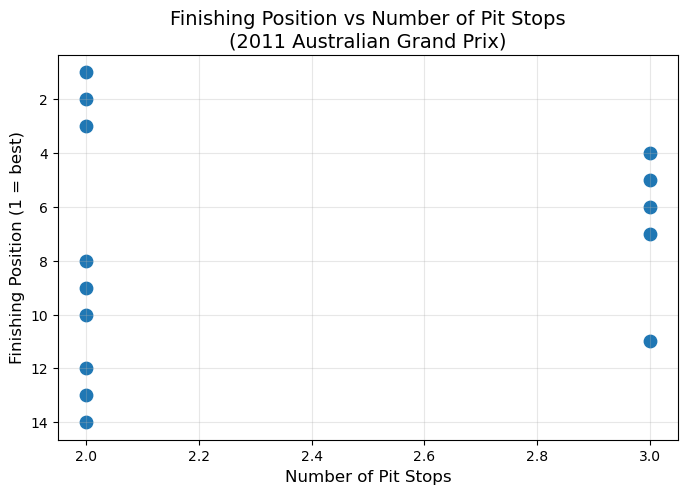

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(race_data["stop"], race_data["position"], s=80)

plt.xlabel("Number of Pit Stops", fontsize=12)
plt.ylabel("Finishing Position (1 = best)", fontsize=12)
plt.title("Finishing Position vs Number of Pit Stops\n(2011 Australian Grand Prix)", fontsize=14)

plt.gca().invert_yaxis()  # So P1 appears at the top
plt.grid(alpha=0.3)
plt.show()

<span style="color: blue; font-size: 1em;">Graph 2: Average Pit Stop Duration vs. Finishing Position</span>

Next, we explored whether the **average length of a driver’s pit stops** affected their finishing result. For each driver, we calculated the mean pit stop duration across all stops and compared this value to their final position in a scatter plot.

The graph shows a mild but noticeable pattern: **drivers with faster pit stop averages tended to finish higher**, while slower pit stop averages corresponded with lower placements. Although the spread of data points is wider than in the stop-count analysis, the trend is still present — most of the higher-finishing drivers clustered toward shorter pit stop times, suggesting that **pit crew efficiency played a meaningful role in race outcome**.

Notably, a few drivers show significantly longer average stop durations, and these drivers finished toward the back of the field. This may reflect slow tire changes, mechanical checks, or more complex repairs that cost valuable time during the race.

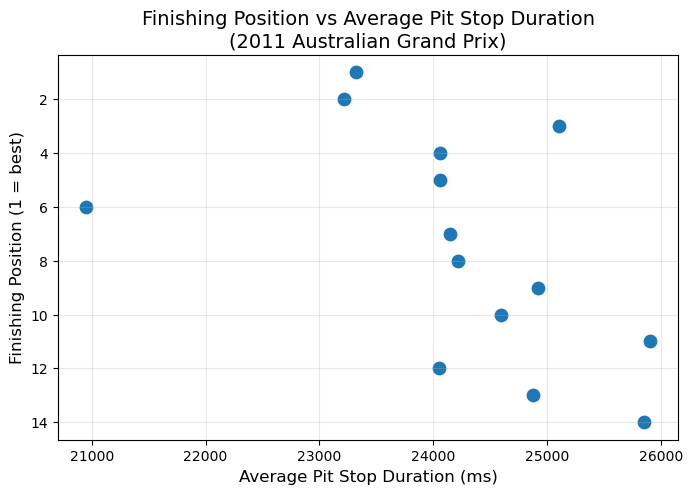

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(race_data["avgStopDuration"], race_data["position"], s=80)

plt.xlabel("Average Pit Stop Duration (ms)", fontsize=12)
plt.ylabel("Finishing Position (1 = best)", fontsize=12)
plt.title("Finishing Position vs Average Pit Stop Duration\n(2011 Australian Grand Prix)", fontsize=14)

plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

<span style="color: blue; font-size: 1em;">Additional Visualization: Pit Stop Count vs. Average Pit Stop Duration</span>

To further understand the differences in pit stop strategy, we created an additional visualization comparing the **number of stops** to the **average pit stop duration** for each driver. This plot helps clarify whether the number of stops is associated with consistently slower (or faster) pit work.

The visualization shows that drivers with **three pit stops** did not necessarily have shorter or more efficient stops. This suggests that making more stops did not compensate through superior pit stop execution. In fact, many of them had equal or longer average durations compared to drivers who only stopped twice. This supports the interpretation that **drivers who pitted three times may have done so out of necessity**, such as resolving mechanical issues or responding to tire degradation rather than executing a deliberate performance-optimized strategy.

By combining all three visualizations, we see the same broader conclusion from multiple angles:
**Drivers who minimized pit stop frequency and maintained efficient pit stop times were more likely to achieve stronger finishing positions.**

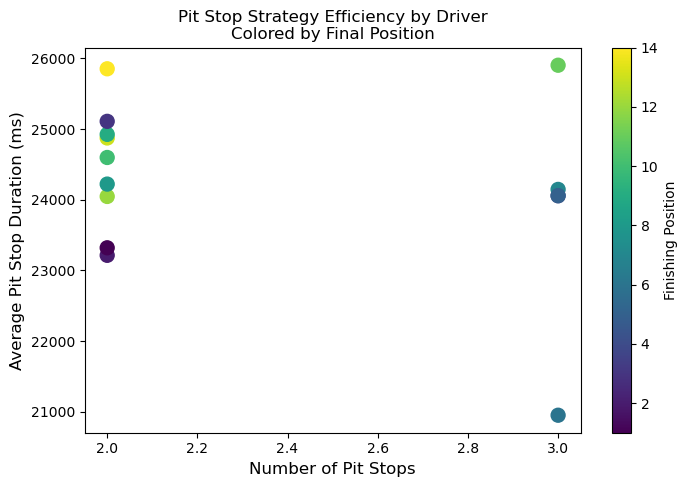

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    race_data["stop"],
    race_data["avgStopDuration"],
    c=race_data["position"],
    cmap="viridis",
    s=100
)

plt.colorbar(label="Finishing Position")
plt.xlabel("Number of Pit Stops", fontsize=12)
plt.ylabel("Average Pit Stop Duration (ms)", fontsize=12)
plt.title("Pit Stop Strategy Efficiency by Driver\nColored by Final Position")

plt.show()

With these patterns established, we now summarize the key insights from our analysis.

<span style="color: blue; font-size: 1.5em;">Conclusion:</span>

Across all three visualizations, a consistent pattern emerges regarding pit stop strategy and performance in the 2011 Australian Grand Prix. Drivers who made **fewer pit stops** and who maintained **faster, more efficient pit stop times** tended to finish higher in the race standings. The strongest evidence comes from the first plot, where every podium finisher completed only two stops, while all drivers who made three stops placed lower. This suggests that minimizing pit lane time was a clear strategic advantage in this race.

The second visualization shows that pit stop efficiency also played a meaningful role—drivers with shorter average pit stop durations generally achieved better results. Several drivers with noticeably slower pit stops finished toward the back, indicating that even small delays in the pit lane can accumulate into significant competitive disadvantages.

Finally, the combined visualization of stop count and average duration reinforces that three-stop strategies were not offset by quicker pit execution. These drivers did not gain back time through faster stops; instead, they often lost both track position and pit lane efficiency.

Taken together, the results suggest that for this race, **the optimal strategy was a balanced one: minimizing the number of pit stops while keeping each stop fast and consistent**. Although we cannot rule out factors such as tire degradation or mechanical reliability influencing pit decisions, the data clearly shows that efficient and limited pit activity aligned closely with stronger finishing outcomes.

Overall, this analysis highlights the strategic importance of pit stop management in Formula One. In races where external variables are held constant, such as this single-race case study, pit stop performance becomes a key differentiator between drivers who finish at the front and those who fall behind.

*Because our analysis focuses on a single race, these patterns reflect race-specific conditions and should not be interpreted as universally applicable across all Formula One events.*